In [2]:
import pandas as pd
pd.set_option("display.max_rows", 50)

import numpy as np
import os, sys
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
plt.rcParams["font.size"] = "11"

from matplotlib.ticker import AutoMinorLocator
# import multiprocessing
import json, argparse

%run ./asset.ipynb
%run ./otypes.ipynb
%run ./reduce_name.ipynb
%run ./match_name.ipynb
%run ./HR.ipynb
%run ./classifier.ipynb

# Configure batch auto-review on fresh QuickSearch_V2 candidates.
sys.argv = [
    'iplotter.ipynb',
    '--idir', '../results/QuickSearch_V2/',
    '--r', '../results/CandidateReport_V2/',
    '--line', 'K'
]
print('Configured args for V2 batch run:', sys.argv[1:])

parser = argparse.ArgumentParser(description='Automatic Spectroscopy Search for Exocomet Transits Tutorial', epilog='ASSET by RBW', allow_abbrev=False)
parser.add_argument('--p', metavar='param.json', default='param.json', help='parameter file name (default:input_param.json)')
parser.add_argument('--star', metavar='star', default='None', help='Individual star you want to look at')
parser.add_argument('--force', metavar='force_star', default='None', help='Force star you want to look at - input dataset name')
parser.add_argument('--nice', metavar='niceness', default=15, help='niceness of job (default: 15)')
parser.add_argument('--line', metavar='line', default='K', help='define what atomic line to use (default: "K")')
parser.add_argument('--cands', metavar='review_cands', default='False', help='review previously flagged as candidates (default: False)')
parser.add_argument('--r', metavar='res-path', default='../results/CandidateReport/', help='path for candidate report (default: CandidateReport/)')
parser.add_argument('--idir', metavar='input-path', default='../results/QuickSearch/', help='path for numpy list of candidates from quicksearch.py (default: QuickSearch/)')
parser.add_argument('--savefig', metavar='fig-path', default='None', help='path to save plots when running iplotter.py just for plots (default: None)')
args, _ = parser.parse_known_args()

os.nice(int(args.nice))

with open(args.p) as paramfile:
    param = json.load(paramfile)

instrument_label = 'UVES'
auto_route_plots = str(args.savefig) == 'None'

if str(args.star) != 'None':
    target = to_reduce(str(args.star))
    try:
        cand_info = find_target(target)
        candidates = [cand_info.Reduced]
        print('The star {} is observed by UVES.'.format(cand_info.Sanitised))
        single_star = True
    except FileNotFoundError:
        print('The star {} ({}) does not exist. Try again!'.format(str(args.star), target))
        sys.exit()
elif str(args.force) != 'None':
    candidates = [str(args.force)]
    single_star = True
else:
    # Input candidate list
    if str(args.cands) == 'False':
        base_name = 'candidates_{}sig_{}cut_{}width'.format(param["threshold"], param["cutoff"], param["width_filt"])
        candidate_files = [f for f in os.listdir(args.idir) if f.startswith(base_name) and f.endswith('.npy')]
        if len(candidate_files) == 0:
            raise FileNotFoundError('No candidate file found in {} matching {}'.format(args.idir, base_name))
        candidate_files.sort(key=lambda f: os.path.getmtime(os.path.join(args.idir, f)), reverse=True)
        selected_file = candidate_files[0]
        print('Using latest QuickSearch file:', selected_file)
        candidates = np.load(os.path.join(args.idir, selected_file), allow_pickle = True)
    else:
        # review_cands = True
        # TODO load candidate numpy array
        candidate_report = pd.read_pickle(args.r + 'candidate_report.pkl')
        all_candidates = candidate_report[candidate_report.Status == 'candidate']
        candidates = all_candidates.Target.to_numpy()
    # candidates = np.array(['hd172555', 'betapic', 'hr7596', 'hr4502', 'hr3702'])
    
    single_star = False

# old_report = pd.read_pickle('CandidateReport/old_candidate_report.pkl')
# newest_report = pd.read_pickle('CandidateReport2/candidate_report.pkl')

if not os.path.exists(args.r):
    os.makedirs(args.r)
    print("new directory {} created!".format(args.r))

Search = ASSET(parameters = param, line=args.line)
HRd = HR_Diagram()
Classifier = Classify(param, args.r)

review_flagged = True

while review_flagged == True:
    look_flagged = None # Flag to note if user wants to review flagged targets
    review_skipped = True

    while review_skipped == True:

        look_skip = None # Flag to note if user wants to review skipped targets
        
        for i,cand in enumerate(candidates):

            plot = False
            Search.ccf = False

            classified = Classifier.candidate_info(cand)
            
            if classified:
                if str(args.savefig) != 'None':
                    print('This star: {} has been classified as {}.'.format(cand, Classifier.previous_report.Status.to_numpy()[0]))

                elif Classifier.flagged:
                    print('This star: {} has already been flagged.'.format(cand))
                elif single_star == True:
                    print('This star: {} has already been classified as {}.'.format(cand, Classifier.previous_report.Status.to_numpy()[0]))
                else:
                    continue
            print('{}:----------------{}/{}--------------------'.format(cand,i+1, len(candidates)))

            star_path = param["dataset"] + '{}/'.format(cand)
            spec_param = Search.spec_analysis(star_path)

            if spec_param == None:
                if single_star == True:
                    print('{}: Not enough spectra for the search to be completed.'.format(cand))
                    sys.exit()
                else:
                    continue
            else:
                new_spectra, med, med_err = spec_param
                ref_spec = med[Search.snr_idxrange]

                corr_med = med.copy()
                if Search.ccf == True:
                    rv_shift = Search.X_corr(corr_med)
                    cond100 = (Search.radial_velocity > rv_shift-50) & (Search.radial_velocity < rv_shift+50)
                    corr_med[cond100] = np.nan

                Classifier.target_info = Search.df            

            # Determine which date column is available
            date_col = 'MJD-OBS' if 'MJD-OBS' in Classifier.target_info.columns else 'Date'

            while Classifier.current_status == None:

                fig = plt.figure(constrained_layout=True, figsize=(10,10))

                gs = GridSpec(8, 2, figure=fig)
                ax1 = fig.add_subplot(gs[0, :]) # otype search dataframe

                ax2 = fig.add_subplot(gs[1:4, 0]) # spec with detection from search
                ax3 = fig.add_subplot(gs[1:4, 1], sharex = ax2) # snr from search

                ax4 = fig.add_subplot(gs[4:7, 0], sharex = ax2) # min snr vs rv position
                ax5 = fig.add_subplot(gs[4:7, 1]) # HR diagram full

                ax6 = fig.add_subplot(gs[7, :])

                fig.suptitle("{} line, Star {}, Reduced: {}, {}: {}".format(args.line, Search.target_san, Search.target_red, instrument_label, Search.target_harps))
                
                simbad_search = get_otypes(Search.target_harps)

                ax1.axis('off')
                try:
                    table = ax1.table(cellText=simbad_search.values,colLabels=simbad_search.columns,loc='center', colWidths=[0.15, 0.4, 0.1, 0.15, 0.1, 0.1])
                    table.auto_set_font_size(False)
                    table.set_fontsize(10)
                except:
                    ax1.text(0.5, 0.5, 'No match with Simbad')

                ax2.set_ylabel('Normalised Flux')
                ax2.set_xlabel('Heliocentric Velocity (km/s)')
                ax2.set_xlim(Search.rv_min,Search.rv_max)

                ax3.set_ylabel('SNR ($\sigma$)')
                ax3.set_xlabel('Heliocentric Velocity (km/s)')
                ax3.hlines(-1 * Search.threshold, Search.rv_min,Search.rv_max, linestyles= 'dashed', linewidth=4, colors='red')
                ax3.hlines(1 * Search.threshold, Search.rv_min,Search.rv_max, linestyles= 'dashed', linewidth=4, colors='red')

                ax4.set_ylabel('min SNR ($\sigma$)')
                ax4.set_xlabel('Heliocentric Velocity (km/s)')

                all_gaia_colours, all_gaia_Mag = HRd.build_HR(HRd.gaia_xmatch, adjust=False)
                target_gaia_info = HRd.get_star_gaia_info(Search.target_red)
                target_gaia_colours, target_gaia_Mag = HRd.build_HR(target_gaia_info, adjust = False)

                ax5.scatter(all_gaia_colours, all_gaia_Mag, s=20, marker = 'o', color = 'grey', alpha = 0.5)
                ax5.scatter(target_gaia_colours, target_gaia_Mag, s=20, marker = 's', color = 'blue')

                ax5.set_ylabel('Gaia Absolute Magnitude')
                ax5.set_xlabel('Gaia G-Rp Colour')
                ax5.set_xlim((-0.4, 1.5))
                ax5.set_ylim((-9,15))
                ax5.invert_yaxis()
                ax5.yaxis.set_minor_locator(AutoMinorLocator())
                ax5.xaxis.set_minor_locator(AutoMinorLocator())

                indices = []
                all_min_SNR = []
                all_rv_pos = []
                all_width = []
                all_abs_depth = []
                all_max_peak = []

                for i in range(len(new_spectra)):

                    detection = False

                    spec = new_spectra[i]

                    corr_spec = spec.copy()
                    if Search.ccf:
                        corr_spec[cond100] = np.nan

                    filtered_spec = spec[Search.snr_idxrange]
                    snr = Search.snr(spec, med, Search.spectra_err[i], med_err)
                        
                    sd = np.std(snr)

                    corr_snr = snr.copy()
                    if Search.ccf == True:
                        corr_snr[cond100] = np.nan

                    corr_snr = corr_snr[Search.snr_idxrange]

                    sig = corr_snr/sd

                    min_detect = np.nanmin(sig)
                    max_detect = np.nanmax(sig)
                    all_min_SNR.append(round(min_detect,2))
                    all_max_peak.append(round(max_detect,2))

                    filtered_rv = Search.radial_velocity[Search.snr_idxrange]
                    rv_detect = filtered_rv[sig == min_detect][0]
                    all_rv_pos.append(round(rv_detect,2))

                    if min_detect < Search.threshold:
                        width = Search.get_width(sig)
                        if width >= Search.width_filter:
                            plot = True
                            detection = True

                            indices.append(i)
                            all_width.append(width)

                            abs_depth = (ref_spec[filtered_rv == rv_detect] - filtered_spec[filtered_rv == rv_detect])/ref_spec[filtered_rv == rv_detect]
                            all_abs_depth.append(round(abs_depth[0],2))

                            ax2.plot(Search.radial_velocity, corr_spec, linewidth = 2,alpha = 0.7, color ='k', zorder= 5)
                            ax3.plot(filtered_rv, sig, linewidth =1.5,color = 'k', alpha= 0.5, zorder = 5)
                            ax4.scatter(rv_detect, min_detect, s=20, marker = 'o', color = 'dodgerblue', alpha = 0.5)
                            ax6.scatter(Classifier.target_info.loc[i , date_col], 1, s=20, marker = 'o', color = 'red', zorder = 5, alpha = 0.5)

                    if detection == False:
                        ax4.scatter(rv_detect, min_detect, s=20, marker = 'o', color = 'grey', alpha = 0.5)
                        ax2.plot(Search.radial_velocity, corr_spec, linewidth = 2,alpha = 0.2, color ='grey', zorder = 0)
                        ax6.scatter(Classifier.target_info.loc[i , date_col], 1, s=20, marker = 'o', color = 'grey', 
                                    zorder = 0, alpha = 0.5)
                        ax3.plot(filtered_rv, sig, linewidth =1,color = 'grey', alpha= 0.3, zorder = 0)
    
                ax2.plot(Search.radial_velocity, corr_med, linewidth = 2.5,color = 'r', label='Median Reference', zorder = 10)
                if Search.ccf:
                    ax2.plot(Search.radial_velocity, med, linewidth = 2.5,color = 'r', linestyle = '--', alpha =0.2, label='Original Median Reference', zorder = 0)
                
                handles, labels = ax2.get_legend_handles_labels()
                spectra_legend = Line2D([0], [0], label='Superimposed spectra', color='g', alpha=0.2)
                spectra_det_legend = Line2D([0], [0], label='Spectra with detection', color='k')
                handles.extend([spectra_legend, spectra_det_legend])
                ax2.legend(handles=handles, loc='lower right', fontsize=9)

                Classifier.target_info['Min_SNR'] = all_min_SNR
                Classifier.target_info['Max_Peak_SNR'] = all_max_peak
                Classifier.target_info['RV_pos'] = all_rv_pos
                Classifier.detection_info = Classifier.target_info.iloc[indices].copy()
                Classifier.detection_info['Abs_width'] = all_width
                Classifier.detection_info['Abs_depth'] = all_abs_depth

                if plot == True:

                    if str(args.savefig) != 'None':
                        plt.savefig(args.savefig + '{}.png'.format(cand), bbox_inches = 'tight', dpi=150)
                        print(cand, 'saved!')
                        Classifier.current_status = 'saved'
                        plt.close(fig)
                        continue

                    if auto_route_plots:
                        Classifier.auto_route(True, Search.rv_min, Search.rv_max, Search.threshold, Search.width_filter, peak_threshold=abs(float(Search.threshold)))
                    else:
                        plt.show()
                        Classifier.ask_user()

                else:
                    if auto_route_plots:
                        Classifier.auto_route(False, Search.rv_min, Search.rv_max, Search.threshold, Search.width_filter, peak_threshold=abs(float(Search.threshold)))
                    elif single_star == True:
                        print('{}: No detection for this star.'.format(cand))
                        plt.show()
                        Classifier.current_status = 'plotted'
                    else:
                        plt.close(fig)
                        Classifier.current_status = 'skipped'

            if single_star == True and auto_route_plots == False:
                sys.exit()
                
            if str(args.savefig) != 'None':
                continue

            save_path = Classifier.classify()

            if save_path != None:
                print('{}: Saving fig...'.format(Search.target_red))
                fig.savefig(save_path + '{}.png'.format(Search.target_red), dpi=150)
                print('{}: Saved fig!'.format(Search.target_red))
            
            plt.close(fig)

        if str(args.savefig) != 'None':
            sys.exit()

        if auto_route_plots:
            review_skipped = False
            continue

        if len(Classifier.skipped) >= 1:
            while (look_skip != 'y') & (look_skip != 'n'):
                look_skip = input('Do you want to review Skipped targets? (y/n) ')
                if look_skip == 'y':
                    review_skipped = True
                    candidates = Classifier.skipped
                    Classifier.skipped = []
                elif look_skip == 'n':
                    review_skipped = False
                    Classifier.skipped = []
                else:
                    print('Answer not recorded. Try again.')
        else:
            review_skipped = False

    if auto_route_plots:
        review_flagged = False
        continue

    # If there are any flagged targets
    if len(Classifier.candidate_report.Target[Classifier.candidate_report.Status == 'flagged'].to_numpy()) >= 1:
        while (look_flagged != 'y') & (look_flagged != 'n'):
            look_flagged = input('Do you want to review Flagged targets? (y/n) ')
            if look_flagged == 'y':
                review_flagged = True
                candidates = Classifier.candidate_report.Target[Classifier.candidate_report.Status == 'flagged'].to_numpy()
            elif look_flagged == 'n':
                review_flagged = False
            else:
                print('Answer not recorded. Try again.')
    else:
        review_flagged = False

print('All stars have been looked at.')
print('Saving progress...')
Classifier.candidate_report.to_pickle(Classifier.cand_report_path)
Classifier.candidate_report.to_html(Classifier.res_path + 'Report.html')
print('Saved!')

Configured args for V2 batch run: ['--idir', '../results/QuickSearch_V2/', '--r', '../results/CandidateReport_V2/', '--line', 'K']
Using latest QuickSearch file: candidates_-3.5sig_1.5cut_2width_V2.npy
new directory ../results/CandidateReport_V2/ created!
wasp31:----------------1/498--------------------


/usr/local/python-3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


wasp31: AUTO -> flagged/peak_3p5_to_4 (max peak 3.86 sigma)
wasp31: Saving fig...
wasp31: Saved fig!
he03254033:----------------2/498--------------------


/usr/local/python-3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


he03254033: AUTO -> candidate/review_single_epoch_marginal
he03254033: Saving fig...
he03254033: Saved fig!
hd323771:----------------3/498--------------------


...

wd2032+188: AUTO -> candidate/review_single_epoch_marginal
wd2032+188: Saving fig...
wd2032+188: Saved fig!
hbc93275:----------------497/498--------------------


/usr/local/python-3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


hbc93275: AUTO -> candidate/review_edge_of_window
hbc93275: Saving fig...
hbc93275: Saved fig!
he04302457:----------------498/498--------------------


/usr/local/python-3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


he04302457: AUTO -> flagged/peak_3p5_to_4 (max peak 3.91 sigma)
he04302457: Saving fig...
he04302457: Saved fig!
All stars have been looked at.
Saving progress...
Saved!


In [37]:
import pandas as pd
pd.set_option("display.max_rows", 50)

import numpy as np
import os, sys
import json
import argparse
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
plt.rcParams["font.size"] = "11"

from IPython import get_ipython


def _ensure_runtime_state():
    """Load the helper notebooks and parameter file when the main setup cell was not run."""
    global param

    if 'param' not in globals():
        parser = argparse.ArgumentParser(description='Automatic Spectroscopy Search for Exocomet Transits Tutorial', epilog='ASSET by RBW', allow_abbrev=False)
        parser.add_argument('--p', metavar='param.json', default='param.json', help='parameter file name (default:input_param.json)')
        parser.add_argument('--star', metavar='star', default='None', help='Individual star you want to look at')
        parser.add_argument('--force', metavar='force_star', default='None', help='Force star you want to look at - input dataset name')
        parser.add_argument('--line', metavar='line', default='K', help='define what atomic line to use (default: "K")')
        args, _ = parser.parse_known_args()

        param_path = args.p
        if not os.path.exists(param_path):
            param_path = os.path.join(os.getcwd(), param_path)
        if not os.path.exists(param_path):
            notebook_dir = os.path.abspath('HR/search') if os.path.exists('HR/search/iplotter.ipynb') else os.getcwd()
            param_path = os.path.join(notebook_dir, 'param.json')
        if os.path.exists(param_path):
            with open(param_path) as paramfile:
                param = json.load(paramfile)
        else:
            raise FileNotFoundError('Could not find param.json for the helper.')

    notebook_dir = os.path.abspath('HR/search') if os.path.exists('HR/search/iplotter.ipynb') else os.getcwd()
    for notebook_name, required_name in [
        ('asset.ipynb', 'ASSET'),
        ('otypes.ipynb', 'get_otypes'),
        ('reduce_name.ipynb', 'to_reduce'),
        ('match_name.ipynb', 'find_target'),
        ('HR.ipynb', 'HR'),
        ('classifier.ipynb', 'Classifier'),
    ]:
        if required_name not in globals():
            notebook_path = os.path.join(notebook_dir, notebook_name)
            if os.path.exists(notebook_path):
                try:
                    get_ipython().run_line_magic('run', notebook_path)
                except Exception:
                    pass

    return param


_ensure_runtime_state()


def _get_save_dir():
    for candidate_root in [os.getcwd(), os.path.dirname(os.getcwd()), os.path.abspath(os.path.join(os.getcwd(), '..', '..'))]:
        if os.path.isdir(os.path.join(candidate_root, 'Images')):
            return os.path.join(candidate_root, 'Images', 'starExamples')
    return os.path.join(os.getcwd(), 'Images', 'starExamples')


def plot_single_star_iplotter(star_names, line='K', save_path=None, show=True):
    """Plot one or more stars sequentially; ask to save after each figure."""
    _ensure_runtime_state()

    if isinstance(star_names, str):
        star_names = [star_names]
    else:
        star_names = list(star_names)

    save_dir = _get_save_dir()
    os.makedirs(save_dir, exist_ok=True)

    def _resolve_target_row(star_name):
        reduced_name = str(star_name)
        if 'to_reduce' in globals():
            try:
                reduced_name = to_reduce(str(star_name))
            except Exception:
                pass

        candidate_paths = [
            '/home/msp25gd/Downloads/res/meta/metadata.pkl',
            os.path.join(os.getcwd(), 'metadata.pkl'),
            os.path.join(os.getcwd(), 'res', 'meta', 'metadata.pkl'),
        ]
        for metadata_path in candidate_paths:
            if os.path.exists(metadata_path):
                metadata = pd.read_pickle(metadata_path)
                break
        else:
            raise FileNotFoundError('Could not find the metadata pickle for the target helper.')

        reduced_key = None
        for candidate in ['Reduced', 'reduced']:
            if candidate in metadata.columns:
                reduced_key = candidate
                break

        if reduced_key is None:
            raise KeyError('The metadata pickle does not contain a Reduced column.')

        matches = metadata[metadata[reduced_key].astype(str).str.lower() == reduced_name.lower()]
        if len(matches) == 0:
            raise FileNotFoundError(f'Could not find a metadata row for {reduced_name}.')
        return matches.iloc[0]

    for idx, star_name in enumerate(star_names, 1):
        print(f'[{idx}/{len(star_names)}] {star_name}')
        cand_info = _resolve_target_row(star_name)

        star_red = str(cand_info.get('Reduced', cand_info.get('reduced', str(star_name))))
        star_san = str(cand_info.get('Sanitised', cand_info.get('sanitised', star_red)))
        star_harps = cand_info.get('HARPS', cand_info.get('Harps', cand_info.get('HARP', None)))
        if star_harps is None:
            star_harps = star_red

        Search = ASSET(parameters=param, line=line)
        Search.ccf = False
        Search.target_san = star_san
        Search.target_red = star_red
        Search.target_harps = star_harps

        star_path = param['dataset'] + '{}/'.format(star_red)
        spec_param = Search.spec_analysis(star_path)
        if spec_param is None:
            raise ValueError(f'Not enough spectra for {star_red}.')

        new_spectra, med, med_err = spec_param
        corr_med = med.copy()

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.0, 6), sharex=True, constrained_layout=True)

        line_label = 'CaII K' if line.upper() == 'K' else line
        fig.suptitle(f"{star_san} ({line_label})")

        ax1.set_ylabel('Normalised Flux')
        ax1.set_xlabel('Heliocentric Velocity (km/s)')
        ax1.set_xlim(Search.rv_min, Search.rv_max)

        ax2.set_ylabel('SNR ($\\sigma$)')
        ax2.set_xlabel('Heliocentric Velocity (km/s)')
        ax2.hlines(-1 * Search.threshold, Search.rv_min, Search.rv_max, linestyles='dashed', linewidth=2, colors='red', alpha=0.7)
        ax2.hlines(1 * Search.threshold, Search.rv_min, Search.rv_max, linestyles='dashed', linewidth=2, colors='red', alpha=0.7)

        for epoch_idx, spec in enumerate(new_spectra):
            snr = Search.snr(spec, med, Search.spectra_err[epoch_idx], med_err)
            sd = np.std(snr)
            corr_snr = snr.copy()[Search.snr_idxrange]
            sig = corr_snr / sd
            filtered_rv = Search.radial_velocity[Search.snr_idxrange]

            color = 'k' if np.nanmin(sig) < Search.threshold else '0.6'
            alpha = 0.65 if color == 'k' else 0.35

            ax1.plot(Search.radial_velocity, spec, linewidth=1.2, color=color, alpha=alpha)
            ax2.plot(filtered_rv, sig, linewidth=1.2, color=color, alpha=alpha)

        ax1.plot(Search.radial_velocity, corr_med, linewidth=2.2, color='r', label='Median Reference', zorder=10)
        ax1.legend(loc='lower right', fontsize=9)

        if show:
            plt.show()

        save_choice = input(f'Save this figure for {star_san}? [y/N] ').strip().lower()
        if save_choice in {'y', 'yes'}:
            safe_name = ''.join(ch if ch.isalnum() or ch in '._-' else '_' for ch in str(star_san))
            target_path = save_path if save_path is not None else os.path.join(save_dir, f'{safe_name}_{line.upper()}.png')
            fig.savefig(target_path, bbox_inches='tight', dpi=150)
            print(f'Saved figure to {target_path}')

        plt.close(fig)

    return None


# Example usage:
# plot_single_star_iplotter(['hd22049', 'betapic'])

[1/7] ec123003224


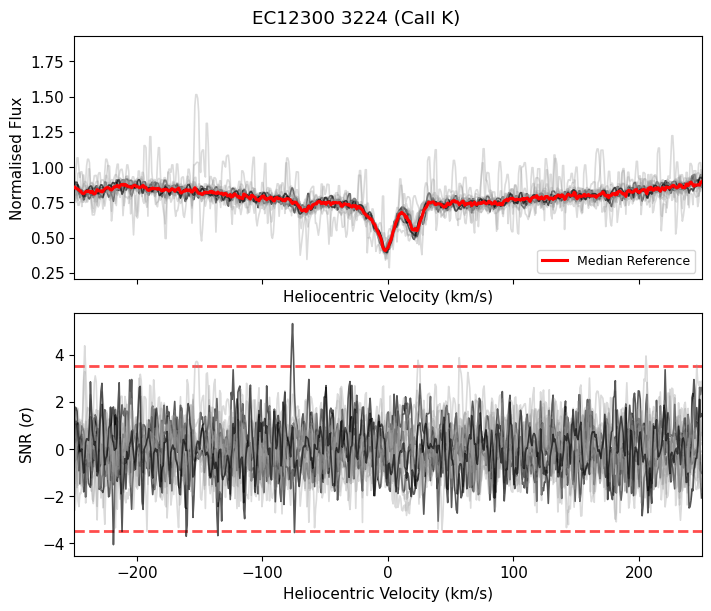

Saved figure to /home/msp25gd/ResearchProjectMSc/Images/starExamples/EC12300_3224_K.png
[2/7] hs1140+2711


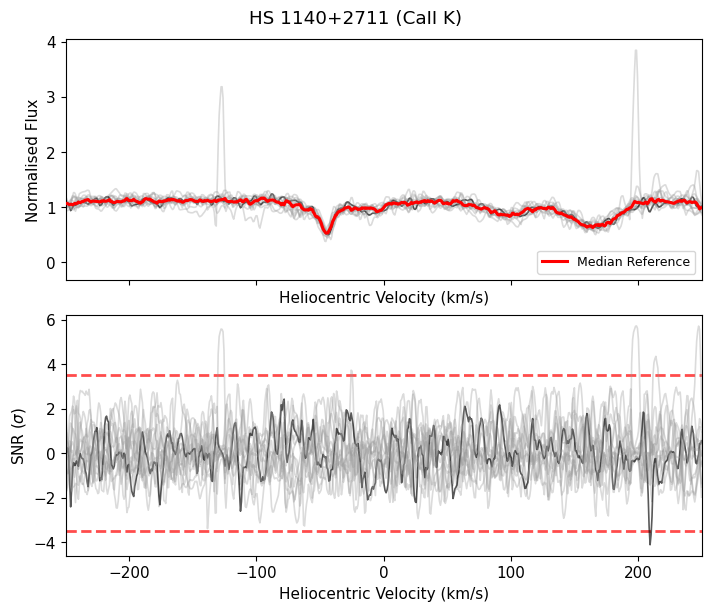

Saved figure to /home/msp25gd/ResearchProjectMSc/Images/starExamples/HS_1140_2711_K.png
[3/7] he03150118


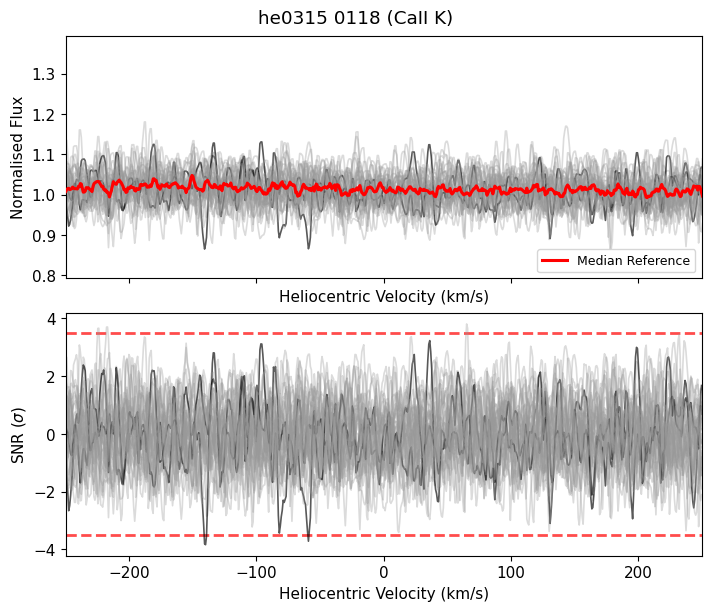

Saved figure to /home/msp25gd/ResearchProjectMSc/Images/starExamples/he0315_0118_K.png
[4/7] hd207278


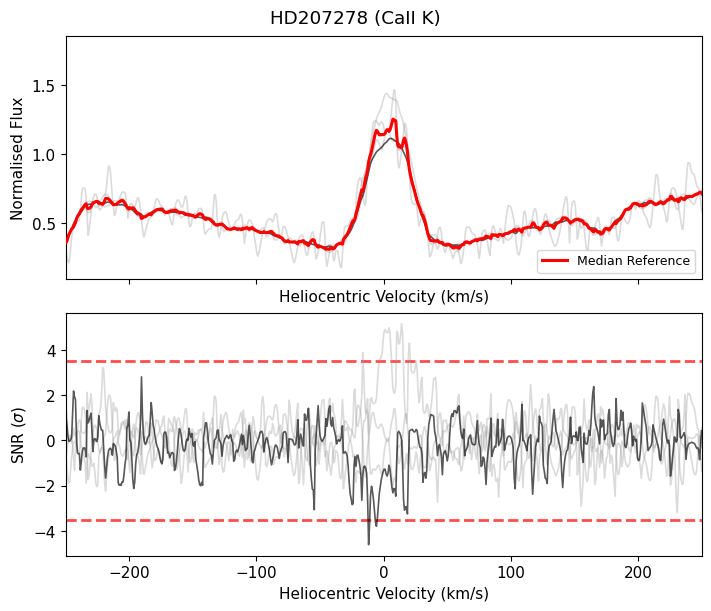

Saved figure to /home/msp25gd/ResearchProjectMSc/Images/starExamples/HD207278_K.png
[5/7] hd358


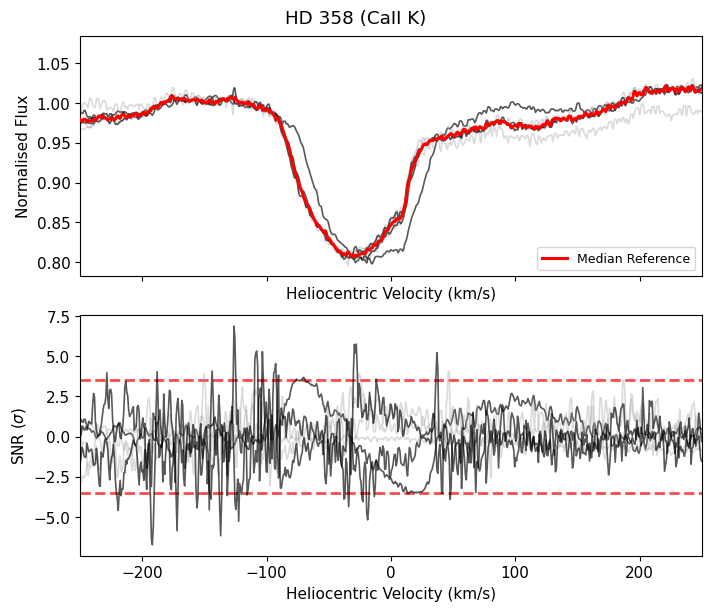

Saved figure to /home/msp25gd/ResearchProjectMSc/Images/starExamples/HD_358_K.png
[6/7] 58aquilae


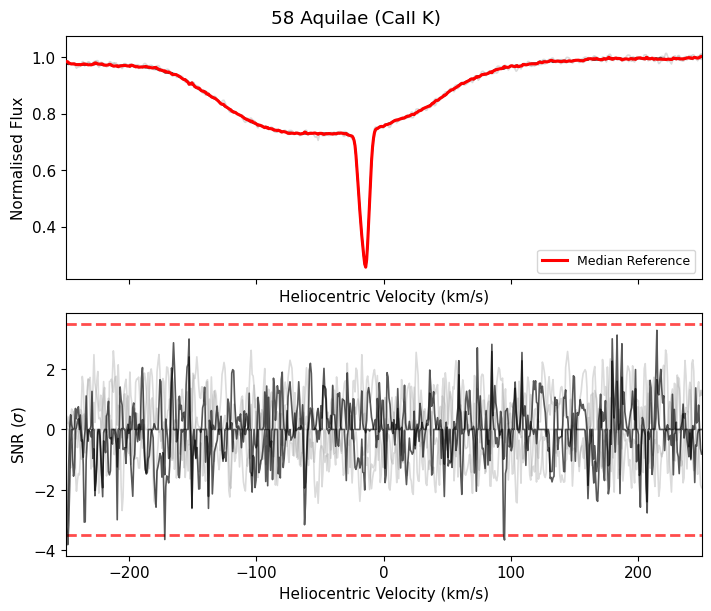

Saved figure to /home/msp25gd/ResearchProjectMSc/Images/starExamples/58_Aquilae_K.png
[7/7] twhya


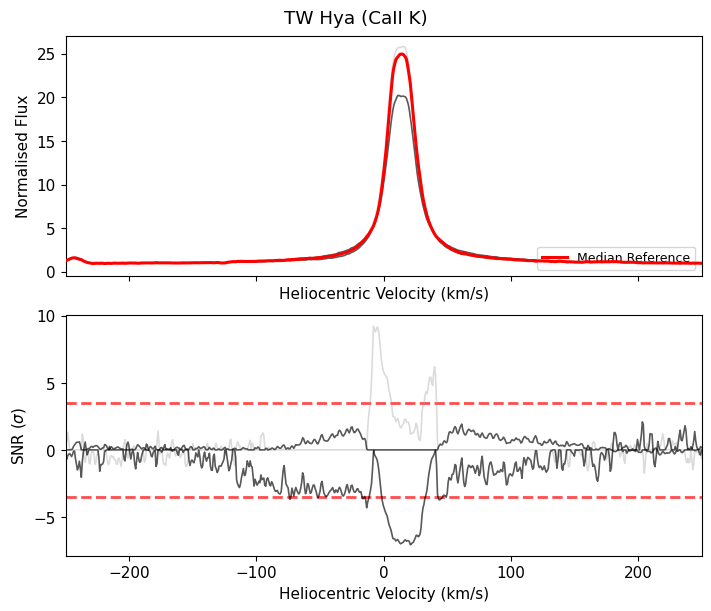

Saved figure to /home/msp25gd/ResearchProjectMSc/Images/starExamples/TW_Hya_K.png


In [38]:
plot_single_star_iplotter(['ec123003224','hs1140+2711','he03150118', 'hd207278', 'hd358', '58aquilae', 'twhya'])


cd-2417504 - K line summary
 epoch  min_sigma  max_sigma  rv_at_min  width  abs_depth
     1      -3.71       3.45    -123.99      7      0.206
     2      -3.36       3.43    -123.99      0      0.201
     3      -3.50       3.45     111.02      2      0.105
     4      -3.13       2.85     207.93      0      0.032
     5      -2.98       3.25     193.43      0      0.032
     6      -2.66       2.52    -185.03      0      0.041
     7      -3.08       2.77      11.83      0      0.042
Threshold dip present: True
Peak above +threshold present: False
Dip repeated in multiple epochs: False


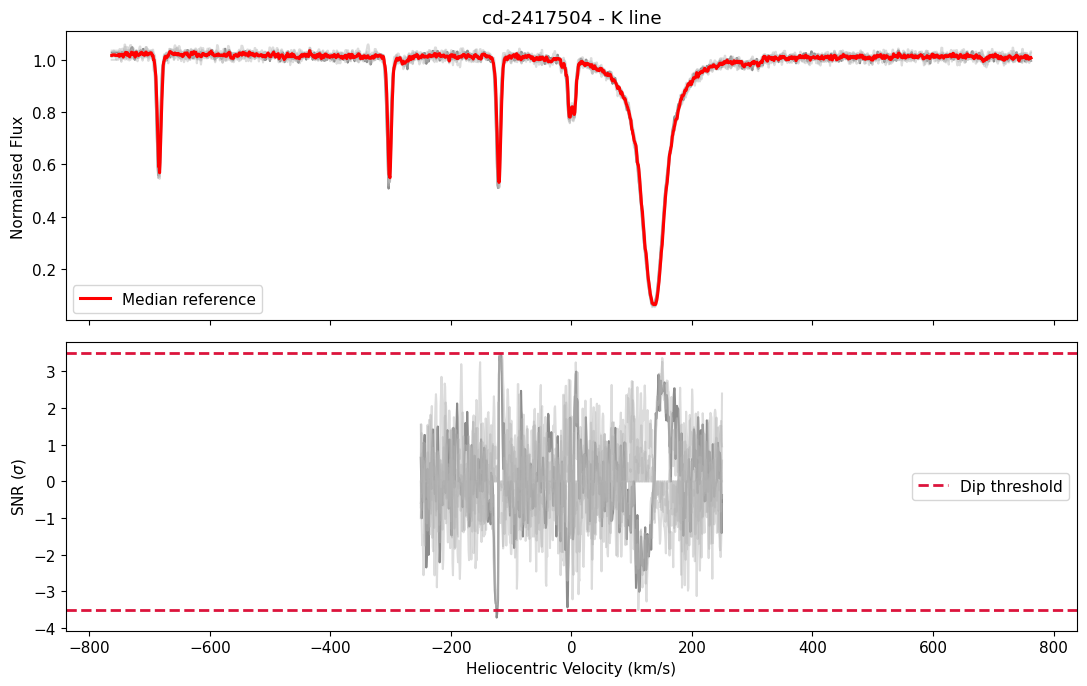


cd-2417504 - H line summary
 epoch  min_sigma  max_sigma  rv_at_min  width  abs_depth
     1      -3.21       3.19     126.69      0      0.256
     2      -2.90       2.79     124.42      0      0.197
     3      -3.08       2.70     124.42      0      0.186
     4      -2.85       2.68       5.67      0      0.057
     5      -2.56       3.02    -209.13      0      0.031
     6      -2.88       2.73    -126.69      0      0.044
     7      -2.60       2.91       9.45      0      0.031
Threshold dip present: False
Peak above +threshold present: False
Dip repeated in multiple epochs: False


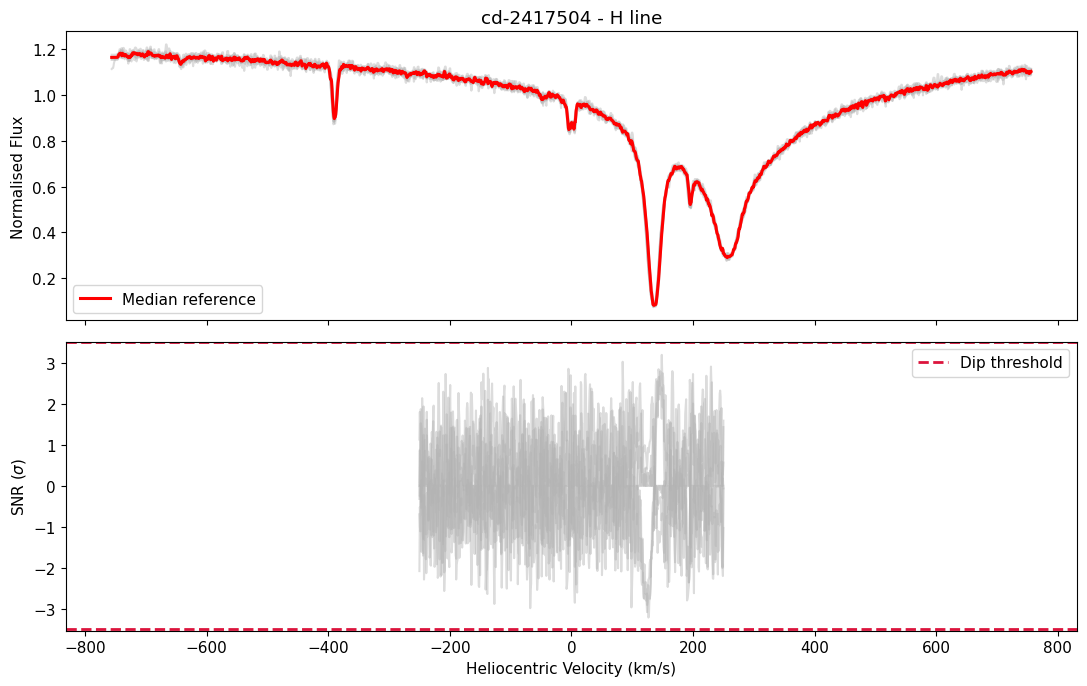

Interpretation guide: an exocomet-like event is usually narrow, redshifted, and transient; a broad dip near the stellar velocity or recurring across epochs is less convincing.


In [5]:
# One-off diagnostic for cd-2417504 without changing the main pipeline.
target_name = 'cd-2417504'
star_path = param['dataset'] + '{}/'.format(target_name)

def inspect_line(line_label):
    local_search = ASSET(parameters=param, line=line_label)
    spec_param = local_search.spec_analysis(star_path)
    if spec_param is None:
        print(f'{target_name} ({line_label}): not enough spectra for inspection.')
        return None

    new_spectra, med, med_err = spec_param
    ref_spec = med[local_search.snr_idxrange]
    summary_rows = []

    for epoch_idx, spec in enumerate(new_spectra):
        filtered_spec = spec[local_search.snr_idxrange]
        snr = local_search.snr(spec, med, local_search.spectra_err[epoch_idx], med_err)
        sd = np.std(snr)
        sig = snr[local_search.snr_idxrange] / sd
        min_detect = float(np.nanmin(sig))
        max_detect = float(np.nanmax(sig))
        filtered_rv = local_search.radial_velocity[local_search.snr_idxrange]
        rv_detect = float(filtered_rv[sig == min_detect][0])
        width = int(local_search.get_width(sig)) if min_detect < local_search.threshold else 0
        abs_depth = float(((ref_spec[filtered_rv == rv_detect] - filtered_spec[filtered_rv == rv_detect]) / ref_spec[filtered_rv == rv_detect])[0])
        summary_rows.append({
            'epoch': epoch_idx + 1,
            'min_sigma': round(min_detect, 2),
            'max_sigma': round(max_detect, 2),
            'rv_at_min': round(rv_detect, 2),
            'width': width,
            'abs_depth': round(abs_depth, 3),
        })

    summary = pd.DataFrame(summary_rows)
    print(f'\n{target_name} - {line_label} line summary')
    print(summary.to_string(index=False))

    has_dip = (summary['min_sigma'] < float(param['threshold'])).any()
    has_peak = (summary['max_sigma'] >= abs(float(param['threshold']))).any()
    repeat_dip = (summary['min_sigma'] < float(param['threshold'])).sum() >= 2

    print('Threshold dip present:', bool(has_dip))
    print('Peak above +threshold present:', bool(has_peak))
    print('Dip repeated in multiple epochs:', bool(repeat_dip))

    fig, (ax_spec, ax_snr) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    for epoch_idx, spec in enumerate(new_spectra):
        snr = local_search.snr(spec, med, local_search.spectra_err[epoch_idx], med_err)
        sd = np.std(snr)
        sig = snr[local_search.snr_idxrange] / sd
        filtered_rv = local_search.radial_velocity[local_search.snr_idxrange]
        color = 'k' if summary.loc[epoch_idx, 'min_sigma'] < float(param['threshold']) else '0.7'
        ax_spec.plot(local_search.radial_velocity, spec, color=color, alpha=0.45)
        ax_snr.plot(filtered_rv, sig, color=color, alpha=0.45)

    ax_spec.plot(local_search.radial_velocity, med, color='red', linewidth=2.2, label='Median reference')
    ax_spec.set_ylabel('Normalised Flux')
    ax_spec.set_title(f'{target_name} - {line_label} line')
    ax_spec.legend(loc='best')

    ax_snr.axhline(float(param['threshold']), color='crimson', linestyle='--', linewidth=2, label='Dip threshold')
    ax_snr.axhline(abs(float(param['threshold'])), color='crimson', linestyle='--', linewidth=2)
    ax_snr.set_ylabel('SNR ($\sigma$)')
    ax_snr.set_xlabel('Heliocentric Velocity (km/s)')
    ax_snr.legend(loc='best')
    plt.tight_layout()
    plt.show()

    return summary

k_summary = inspect_line('K')
h_summary = inspect_line('H')

print('Interpretation guide: an exocomet-like event is usually narrow, redshifted, and transient; a broad dip near the stellar velocity or recurring across epochs is less convincing.')